In [ ]:
## import libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Flatten,
    BatchNormalization
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.applications import VGG16

I0000 00:00:1776447245.490097  129569 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
## data set path and parameters
train_path = "data/split_new/ddd/train"
val_path   = "data/split_new/ddd/val"
test_path  = "data/split_new/ddd/test"

img_height = 128
img_width  = 128
batch_size = 32

print("Train Path :", train_path)
print("Val Path   :", val_path)
print("Test Path  :", test_path)

Train Path : data/split_new/ddd/train
Val Path   : data/split_new/ddd/val
Test Path  : data/split_new/ddd/test


In [3]:
## data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.10,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(128,128),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True
)

val_generator = test_datagen.flow_from_directory(
    val_path,
    target_size=(128,128),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(128,128),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 24291 images belonging to 2 classes.
Found 7454 images belonging to 2 classes.
Found 9719 images belonging to 2 classes.


In [4]:
print(train_generator.class_indices)

{'drowsy': 0, 'non_drowsy': 1}


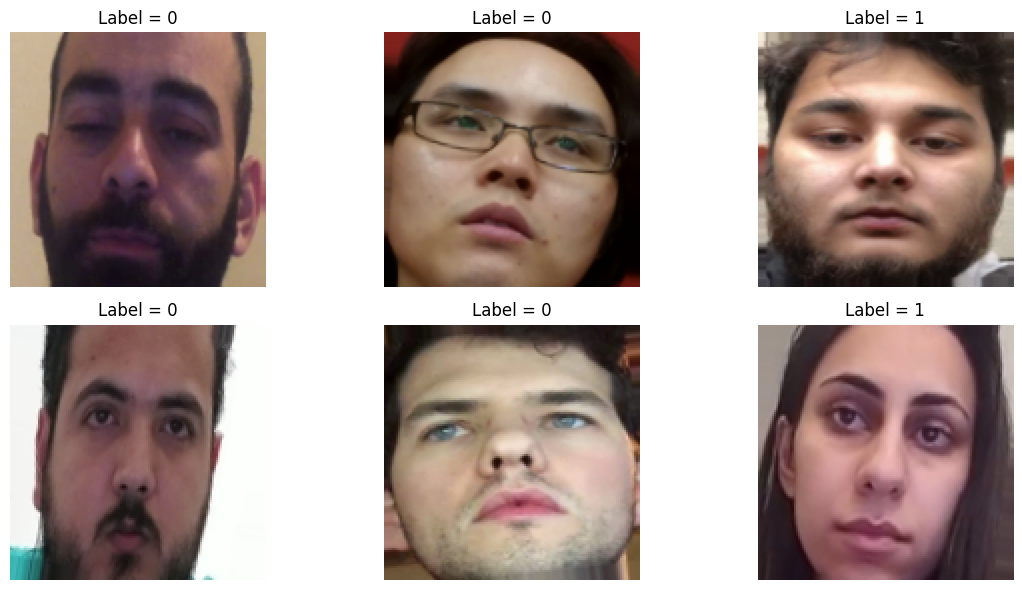

In [5]:
images, labels = next(train_generator)

plt.figure(figsize=(12,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title("Label = " + str(int(labels[i])))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
### load pre-trained vgg16
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

print("VGG16 base loaded.")

W0000 00:00:1776447418.061343  129771 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1776447418.155164  129569 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


VGG16 base loaded.


In [7]:
### freeze base layers
for layer in base_model.layers:
    layer.trainable = False

print("All VGG16 layers frozen.")

All VGG16 layers frozen.


In [8]:
## building full model

model = Sequential()

model.add(base_model)
model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,846,145 (64.26 MB)

 Trainable params: 2,130,945 (8.13 MB)

 Non-trainable params: 14,715,200 (56.13 MB)

In [9]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3
)

print("Callbacks ready.")

Callbacks ready.


In [10]:
## train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20


I0000 00:00:1776447507.386025  129569 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


760/760 ━━━━━━━━━━━━━━━━━━━━ 561s 736ms/step - accuracy: 0.9835 - loss: 0.0448 - val_accuracy: 0.4555 - val_loss: 6.9226 - learning_rate: 0.0010
Epoch 2/20
760/760 ━━━━━━━━━━━━━━━━━━━━ 566s 745ms/step - accuracy: 0.9949 - loss: 0.0146 - val_accuracy: 0.3711 - val_loss: 4.6859 - learning_rate: 0.0010
Epoch 3/20
760/760 ━━━━━━━━━━━━━━━━━━━━ 564s 742ms/step - accuracy: 0.9953 - loss: 0.0146 - val_accuracy: 0.4997 - val_loss: 5.2343 - learning_rate: 0.0010
Epoch 4/20
760/760 ━━━━━━━━━━━━━━━━━━━━ 579s 762ms/step - accuracy: 0.9963 - loss: 0.0107 - val_accuracy: 0.5333 - val_loss: 3.8299 - learning_rate: 0.0010
Epoch 5/20
760/760 ━━━━━━━━━━━━━━━━━━━━ 566s 745ms/step - accuracy: 0.9977 - loss: 0.0075 - val_accuracy: 0.5474 - val_loss: 4.8500 - learning_rate: 0.0010
Epoch 6/20
760/760 ━━━━━━━━━━━━━━━━━━━━ 568s 748ms/step - accuracy: 0.9981 - loss: 0.0067 - val_accuracy: 0.5152 - val_loss: 5.9640 - learning_rate: 0.0010
Epoch 7/20
760/760 ━━━━━━━━━━━━━━━━━━━━ 594s 781ms/step - accuracy: 0.9986 

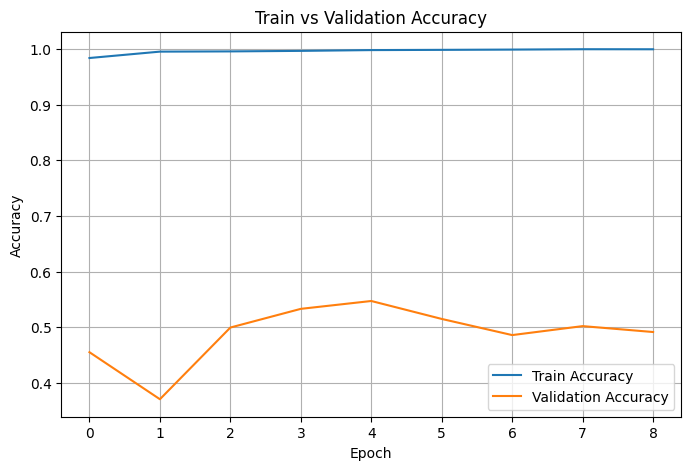

In [11]:
### plot accuracy
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Train vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

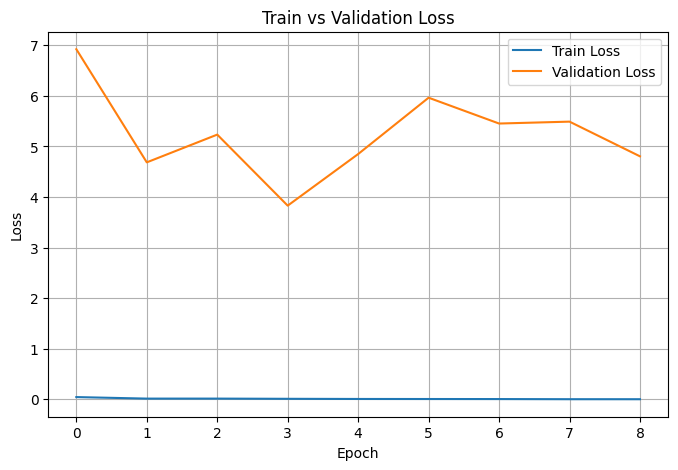

In [12]:
### plot loss
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Train vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
### test accuracy
test_loss, test_acc = model.evaluate(test_generator)

print("Test Accuracy =", round(test_acc*100,2), "%")

304/304 ━━━━━━━━━━━━━━━━━━━━ 171s 563ms/step - accuracy: 0.5519 - loss: 2.1393
Test Accuracy = 55.19 %


In [15]:
test_generator.reset()

pred_prob = model.predict(test_generator)
pred = (pred_prob > 0.5).astype(int).reshape(-1)

true = test_generator.classes

304/304 ━━━━━━━━━━━━━━━━━━━━ 172s 564ms/step


In [16]:
## precision,recall,f1score
print(classification_report(
    true,
    pred,
    target_names=["drowsy","non_drowsy"]
))

              precision    recall  f1-score   support

      drowsy       0.53      0.74      0.62      4813
  non_drowsy       0.59      0.36      0.45      4906

    accuracy                           0.55      9719
   macro avg       0.56      0.55      0.54      9719
weighted avg       0.56      0.55      0.54      9719



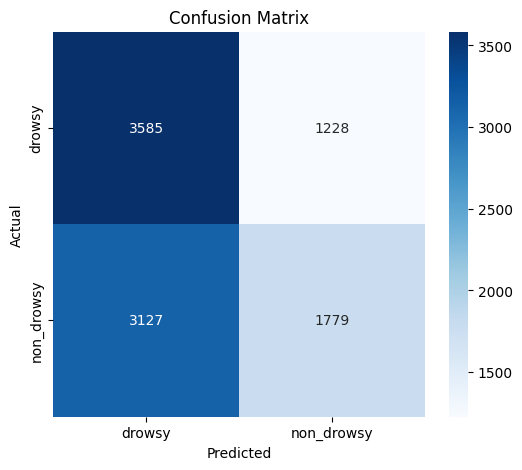

In [17]:
#### confusion matrix
cm = confusion_matrix(true, pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["drowsy","non_drowsy"],
    yticklabels=["drowsy","non_drowsy"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

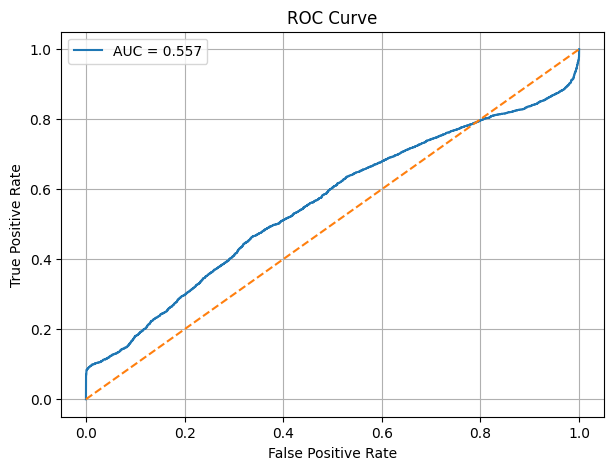

ROC-AUC = 0.557


In [18]:
## ROC-AUC
fpr, tpr, thresholds = roc_curve(true, pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label="AUC = %.3f" % roc_auc)
plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

print("ROC-AUC =", round(roc_auc,3))

## visualization

In [20]:
###Store Filenames and Create Label Map
files = test_generator.filenames

label_map = {
    0: "drowsy",
    1: "non_drowsy"
}

print("Total Test Files:", len(files))

Total Test Files: 9719


In [21]:
### helper function to get person id
import os
import re

def get_prefix(filepath):
    
    name = os.path.basename(filepath)
    
    match = re.match(r"[A-Za-z]+", name)
    
    return match.group()

print(get_prefix("drowsy/A001.png"))
print(get_prefix("non_drowsy/za100.png"))

A
za


In [22]:
### create 4 different groups
correct_drowsy = []
wrong_drowsy = []

correct_non = []
wrong_non = []

for i in range(len(true)):
    
    t = true[i]
    p = pred[i]

    # true drowsy
    if t == 0:
        
        if p == 0:
            correct_drowsy.append(i)
        else:
            wrong_drowsy.append(i)

    # true non_drowsy
    else:
        
        if p == 1:
            correct_non.append(i)
        else:
            wrong_non.append(i)

print("Correct Drowsy    :", len(correct_drowsy))
print("Wrong Drowsy      :", len(wrong_drowsy))
print("Correct Non       :", len(correct_non))
print("Wrong Non         :", len(wrong_non))

Correct Drowsy    : 3585
Wrong Drowsy      : 1228
Correct Non       : 1779
Wrong Non         : 3127


In [ ]:
### function to pick different person
def pick_unique(index_list, n=5):
    
    selected = []
    used_persons = set()

    for idx in index_list:
        
        person = get_prefix(files[idx]).lower()

        if person not in used_persons:
            selected.append(idx)
            used_persons.add(person)

        if len(selected) == n:
            break

    return selected

print("Function Ready")













Function Ready


In [24]:
## select images from each catagory
sample_cd = pick_unique(correct_drowsy, 5)
sample_wd = pick_unique(wrong_drowsy, 5)

sample_cn = pick_unique(correct_non, 5)
sample_wn = pick_unique(wrong_non, 5)

print("Correct Drowsy Selected :", len(sample_cd))
print("Wrong Drowsy Selected   :", len(sample_wd))
print("Correct Non Selected    :", len(sample_cn))
print("Wrong Non Selected      :", len(sample_wn))

Correct Drowsy Selected : 5
Wrong Drowsy Selected   : 5
Correct Non Selected    : 4
Wrong Non Selected      : 4


In [25]:
selected = sample_cd + sample_wd + sample_cn + sample_wn

print("Total Selected Images:", len(selected))

Total Selected Images: 18


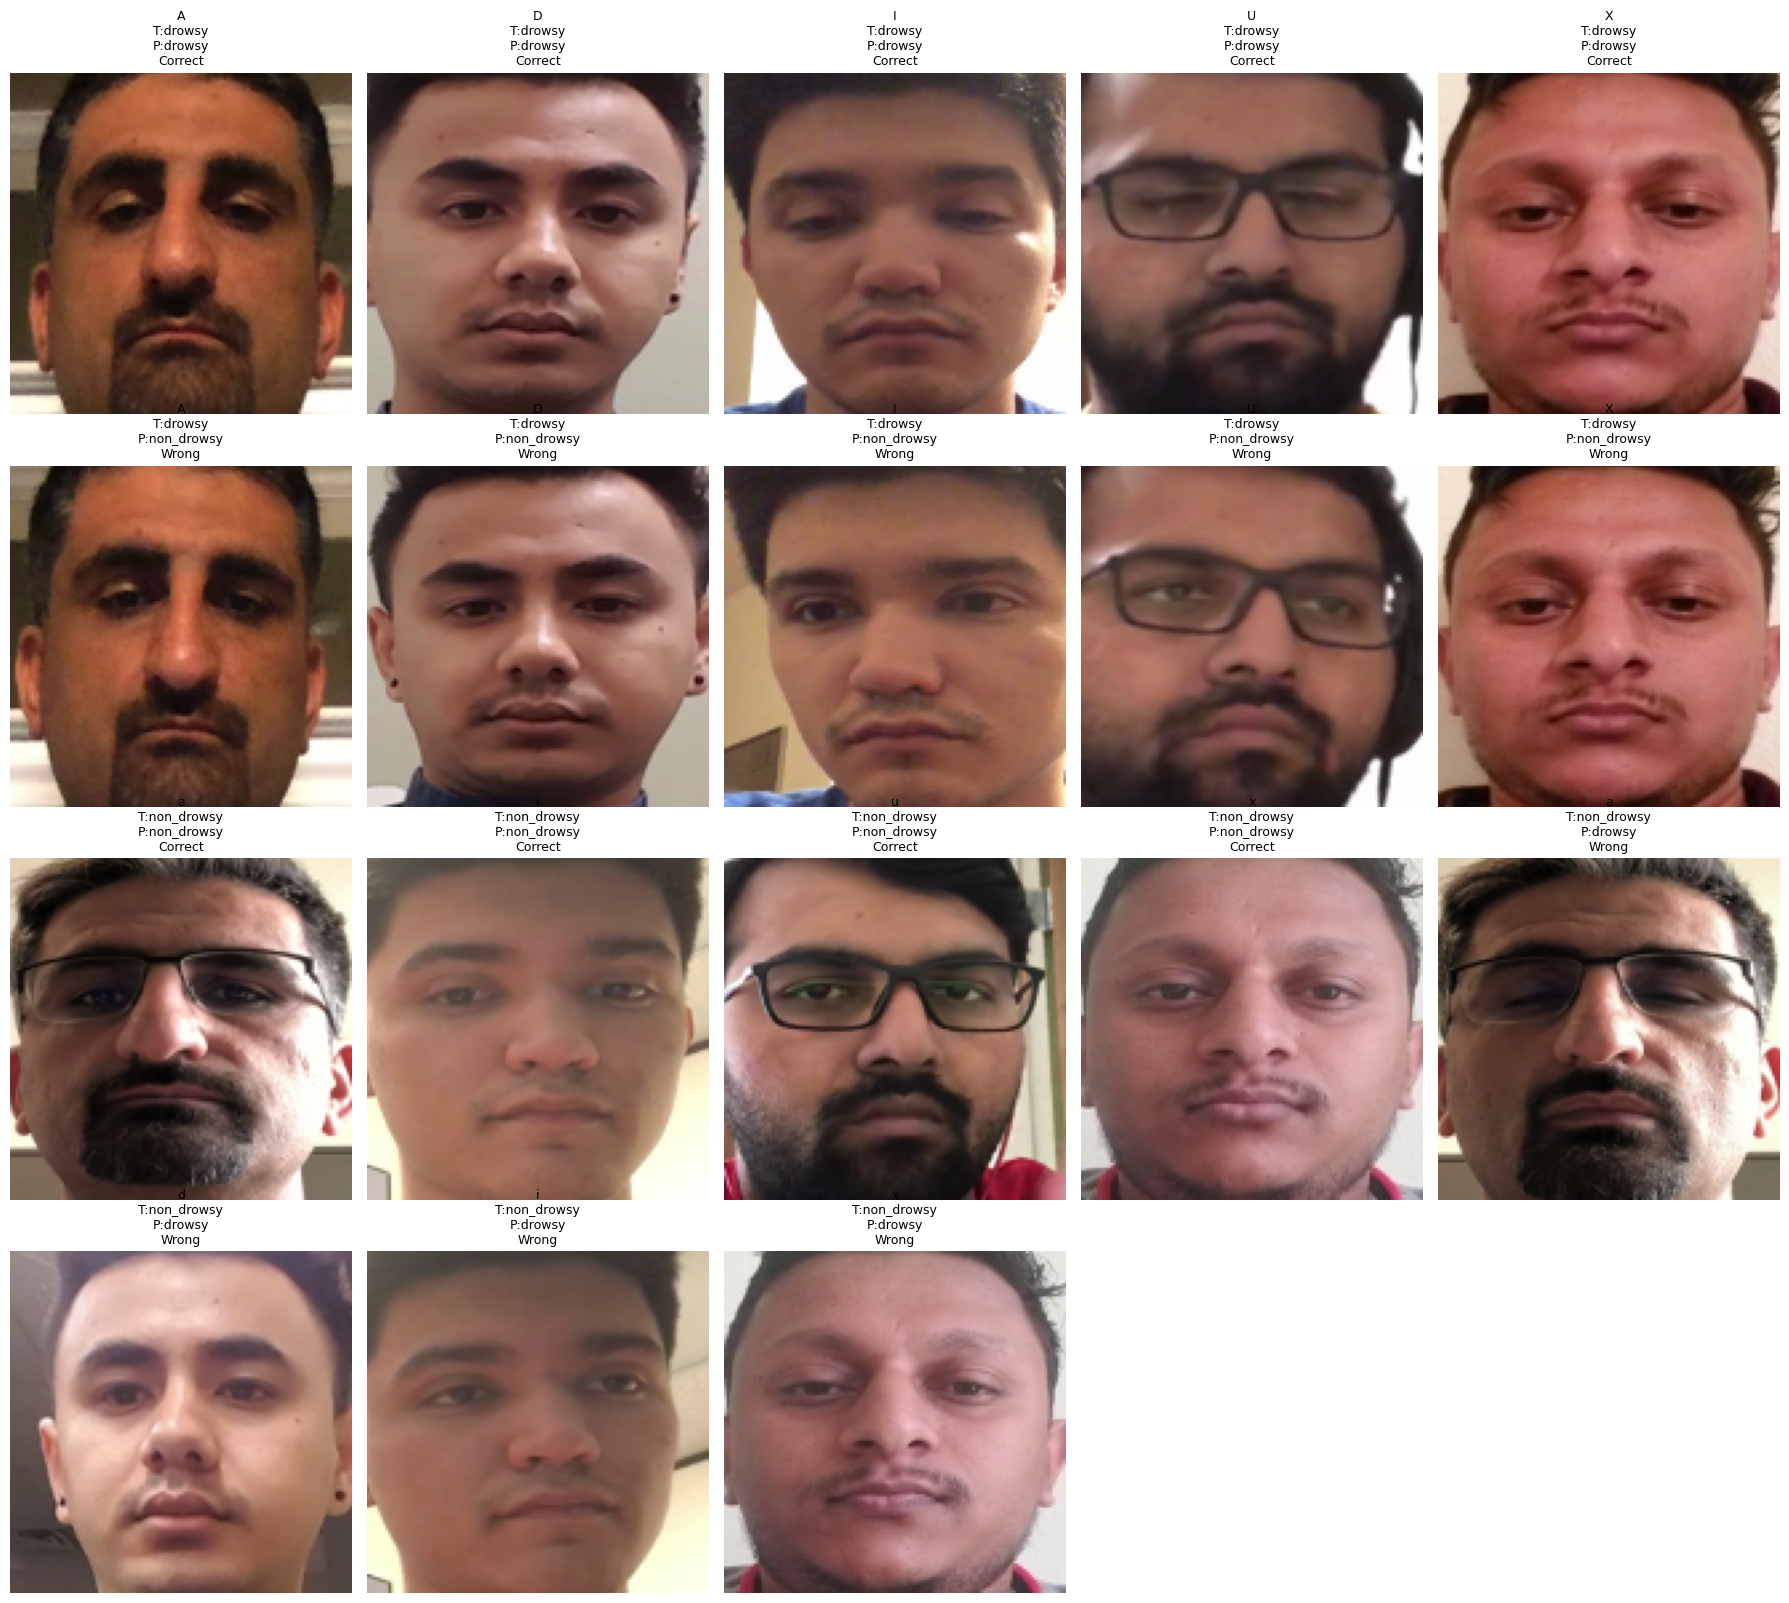

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,16))

for i, idx in enumerate(selected):

    img_path = os.path.join(test_path, files[idx])
    img = plt.imread(img_path)

    person = get_prefix(files[idx])

    t = true[idx]
    p = pred[idx]

    true_label = label_map[t]
    pred_label = label_map[p]

    result = "Correct" if t == p else "Wrong"

    plt.subplot(4,5,i+1)
    plt.imshow(img)

    plt.title(
        f"{person}\nT:{true_label}\nP:{pred_label}\n{result}",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()